### 어디에 어떤 숙소가 강한가 - 히트맵을 통해 알아보기

- (트랙별로) `neighbourhood_group × room_type` 히트맵
    - 평균/중앙값 가격
    - 평균/중앙값 점유(또는 점유율)
    - 평균/중앙값 예상매출
- Top N 동네 랭킹(단, 샘플 수 최소 기준 걸기: 예 50개 이상)

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../공유/final_cleaned_airbnb.csv')
df.shape

(19861, 60)

In [29]:
df['review_scores_location'].describe()

count    13341.000000
mean         4.726688
std          0.402535
min          1.000000
25%          4.630000
50%          4.820000
75%          5.000000
max          5.000000
Name: review_scores_location, dtype: float64

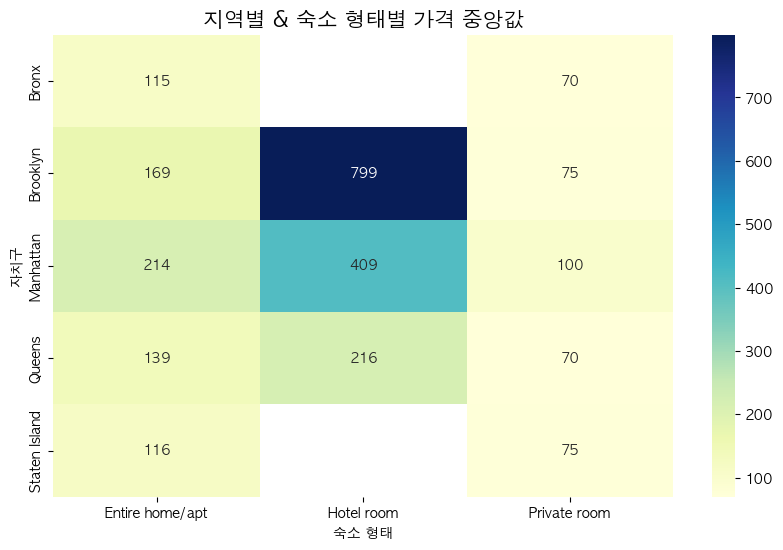

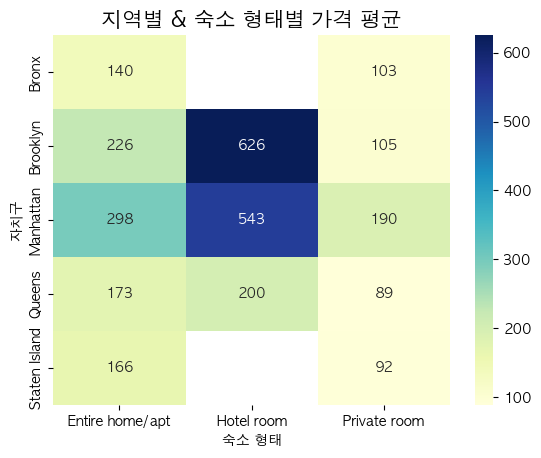

<Figure size 640x480 with 0 Axes>

In [30]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False #마이너스 기호 깨짐 방지

#지역X숙소 형태별 가격 히트맵 (어느 지역에 어떤 방이 비싼지) / 평균(mean)과 중앙값 가격 히트맵
#중앙값
plt.figure(figsize=(10, 6))
pivot_price = df.pivot_table(index='neighbourhood_group_cleansed', columns='room_type', values='price', aggfunc='median')

sns.heatmap(pivot_price, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('지역별 & 숙소 형태별 가격 중앙값', fontsize=15)
plt.xlabel('숙소 형태')
plt.ylabel('자치구')
plt.show()

#평균
pivot_price_mean = df.pivot_table(index='neighbourhood_group_cleansed', columns='room_type', values='price', aggfunc='mean')
sns.heatmap(pivot_price_mean, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('지역별 & 숙소 형태별 가격 평균', fontsize=15)
plt.xlabel('숙소 형태')
plt.ylabel('자치구')
plt.show()

plt.tight_layout()
plt.show()

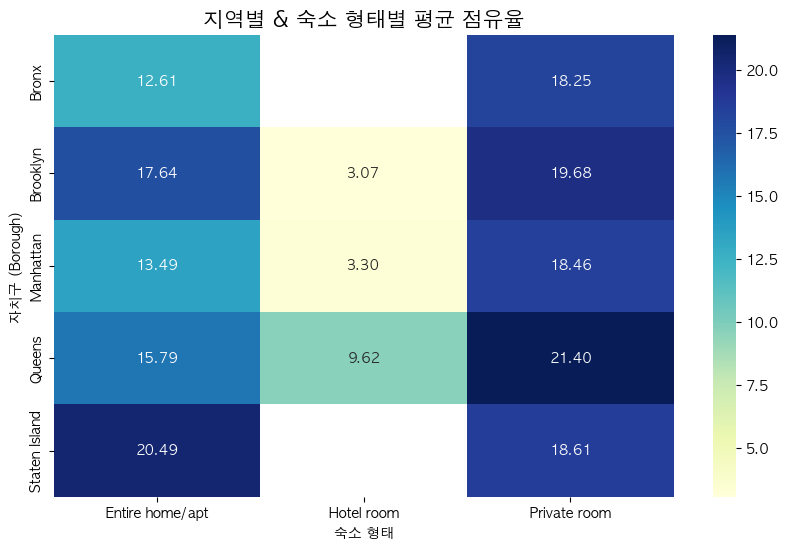

In [31]:
#지역×숙소형태별 점유율 히트맵
#점유율(occupancy_rate) 히트맵
plt.figure(figsize=(10, 6))
pivot_occ = df.pivot_table(index='neighbourhood_group_cleansed', columns='room_type', values='occupancy_rate', aggfunc='mean')

#점유율에 100을 곱해서 %로 표시
pivot_occ = pivot_occ * 100

sns.heatmap(pivot_occ, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('지역별 & 숙소 형태별 평균 점유율', fontsize=15)
plt.xlabel('숙소 형태')
plt.ylabel('자치구 (Borough)')
plt.show()

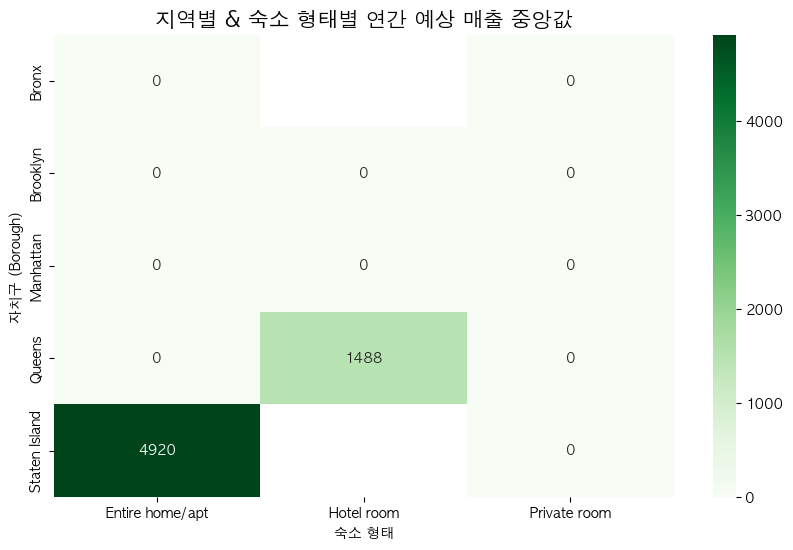

In [32]:
#지역×숙소 형태별 예상 매출 히트맵
#예상매출(estimated_revenue_l365d)
plt.figure(figsize=(10, 6))
pivot_rev = df.pivot_table(index='neighbourhood_group_cleansed', columns='room_type', values='estimated_revenue_l365d', aggfunc='median')

sns.heatmap(pivot_rev, annot=True, fmt=".0f", cmap="Greens")
plt.title('지역별 & 숙소 형태별 연간 예상 매출 중앙값', fontsize=15)
plt.xlabel('숙소 형태')
plt.ylabel('자치구 (Borough)')
plt.show()

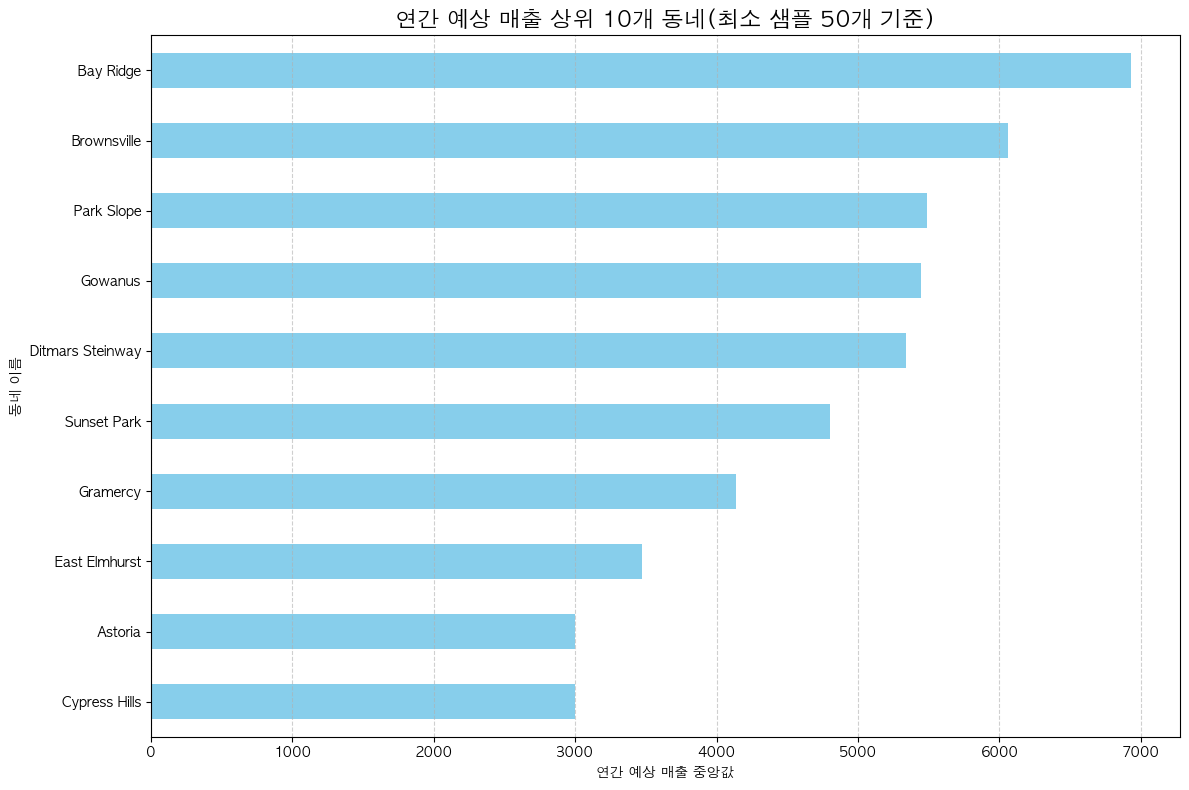

In [33]:
#샘플 수(숙소개수) 50개 이상인 동네 필터링
n_counts = df['neighbourhood_cleansed'].value_counts()
valid_neighborhoods = n_counts[n_counts >= 50].index
df_filtered = df[df['neighbourhood_cleansed'].isin(valid_neighborhoods)]

#동네별 예상 매출 중앙값 상위 10개
top_10_hoods = df_filtered.groupby('neighbourhood_cleansed')['estimated_revenue_l365d'].median().sort_values(ascending=False).head(10)

#시각화
plt.figure(figsize=(12, 8))
top_10_hoods.plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis() 
plt.title('연간 예상 매출 상위 10개 동네(최소 샘플 50개 기준)', fontsize=16)
plt.xlabel('연간 예상 매출 중앙값')
plt.ylabel('동네 이름')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

매출 1위 동네(분석타켓): Bay Ridge


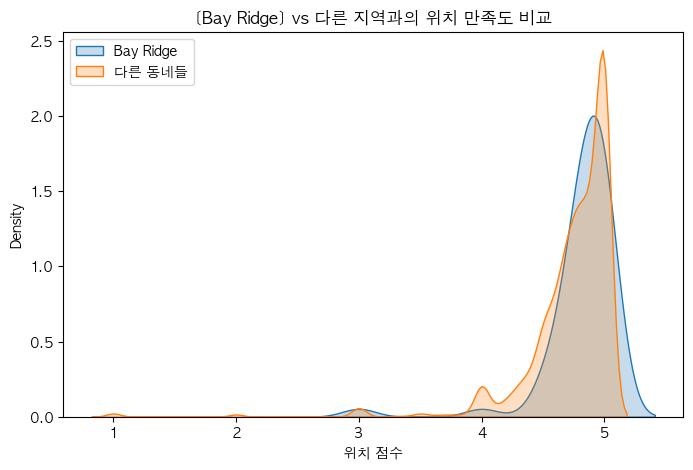

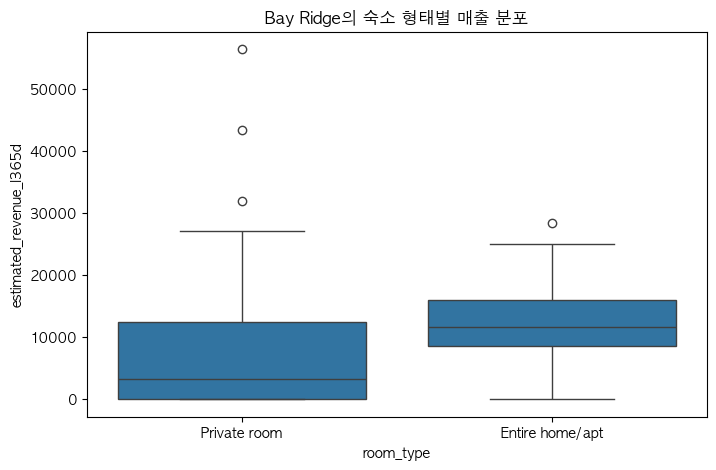

NameError: name 'count_amenities' is not defined

In [34]:
import ast

#샘플 50개 이상 중 매출 중앙값 1위 동네 찾기
n_counts = df['neighbourhood_cleansed'].value_counts()
valid_hoods = n_counts[n_counts >= 50].index
top_hood = df[df['neighbourhood_cleansed'].isin(valid_hoods)].groupby('neighbourhood_cleansed')['estimated_revenue_l365d'].median().idxmax()

print(f"매출 1위 동네(분석타켓): {top_hood}")

#데이터 분리 해주기(1위 동네와 나머지 동네로)
target_df = df[df['neighbourhood_cleansed'] == top_hood]
other_df = df[df['neighbourhood_cleansed'] != top_hood]

#분석 A: 위치 만족도 비교
plt.figure(figsize=(8, 5))
sns.kdeplot(target_df['review_scores_location'], label=f'{top_hood}', fill=True)
sns.kdeplot(other_df['review_scores_location'], label='다른 동네들', fill=True)
plt.title(f'[{top_hood}] vs 다른 지역과의 위치 만족도 비교')
plt.xlabel('위치 점수')
plt.legend()
plt.show()

#분석 B: 어떤 방 타입이 매출을 견인 해주는가?
plt.figure(figsize=(8, 5))
sns.boxplot(x='room_type', y='estimated_revenue_l365d', data=target_df)
plt.title(f'{top_hood}의 숙소 형태별 매출 분포')
plt.show()

#분석 C: 편의시설(Amenities) 분석
def get_len_safe(x): 
    try: 
        if pd.isna(x): return 0 
        return len(ast.literal_eval(x))
    except:
        return 0
    
top_amenities = count_amenities(target_df['amenities']).head(10)

plt.figure(figsize=(10, 6))
top_amenities.plot(kind='bar', color='orange')
plt.title(f'{top_hood} 인기 숙소들의 필수 편의시설 Top 10')
plt.ylabel('보유 숙소 수')
plt.xticks(rotation=45)
plt.show()

점유율과 변수들 간의 상관계수
occupancy_rate            1.000000
number_of_reviews         0.356004
review_scores_location    0.067332
review_scores_rating      0.020698
accommodates             -0.078490
price                    -0.106225
Name: occupancy_rate, dtype: float64


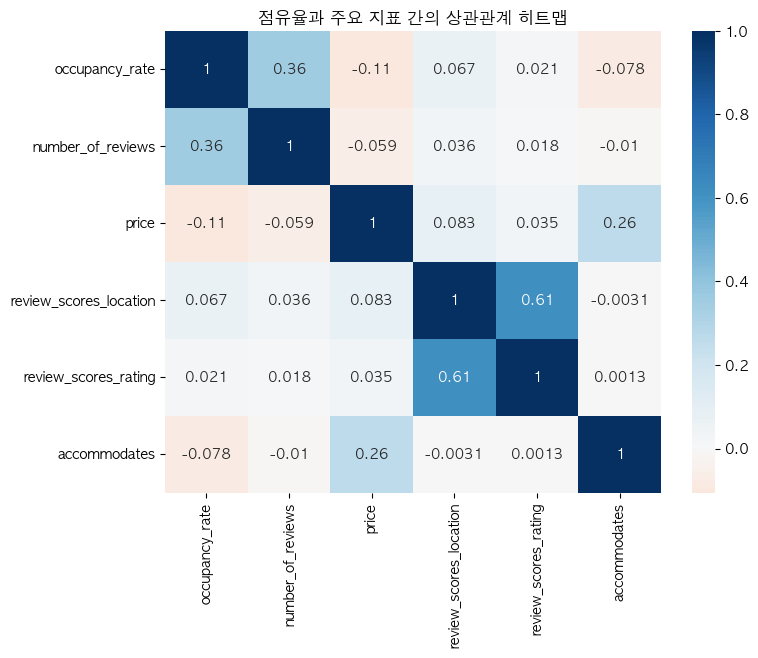

In [ ]:
#수치형 데이터들만 모아서 점유율과의 상관계수 계산
cols = ['occupancy_rate', 'number_of_reviews', 'price', 'review_scores_location', 'review_scores_rating', 'accommodates']
correlation_matrix = df[cols].corr()

# 점유율(occupancy_rate) 기준 정렬해서 보기
print("점유율과 변수들 간의 상관계수")
print(correlation_matrix['occupancy_rate'].sort_values(ascending=False))

#히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title('점유율과 주요 지표 간의 상관관계 히트맵')
plt.show()

점유율과 변수들 간의 상관계수
occupancy_rate            1.000000
number_of_reviews         0.356004
review_scores_location    0.067332
review_scores_rating      0.020698
accommodates             -0.078490
price                    -0.106225
Name: occupancy_rate, dtype: float64


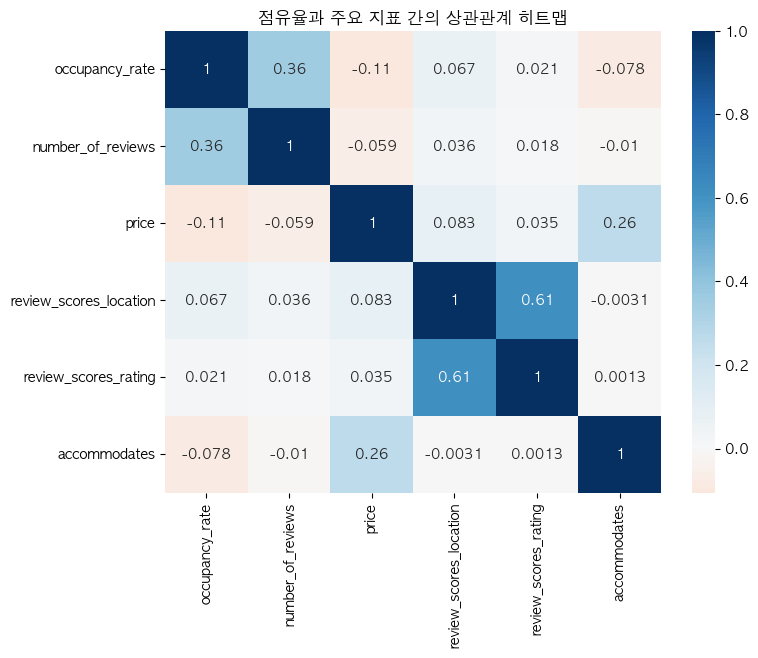

In [ ]:
#수치형 데이터들만 모아서 점유율과의 상관계수 계산
cols = ['occupancy_rate', 'number_of_reviews', 'price', 'review_scores_location', 'review_scores_rating', 'accommodates']
correlation_matrix = df[cols].corr()

# 점유율(occupancy_rate) 기준 정렬해서 보기
print("점유율과 변수들 간의 상관계수")
print(correlation_matrix['occupancy_rate'].sort_values(ascending=False))

#히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title('점유율과 주요 지표 간의 상관관계 히트맵')
plt.show()

In [ ]:
def recommend_investor(df, persona, initial_investment, top_n=5):
    #1.조건 필터링: 사용자 페르소나(운영형태, 방 타입, 최소 인원, 지역)에 맞는 데이터만 추출
    filtered = df[
        (df['property_regulation_type'] == persona['property_regulation_type']) &
        (df['room_type'] == persona['room_type']) &
        (df['accommodates'] >= persona['accommodates_min']) &
        (df['neighbourhood_group_cleansed'] == persona['neighbourhood_group_cleansed'])
    ]
    #데이터가 없을 경우 예외 처리
    if filtered.empty:
        print("조건 수정 필요")
        return pd.DataFrame()
    
    #2. 분석 지표 설정: 시장의 활성도를 파악하기 위한 리뷰 관련 컬럼들
    segment_cols = ['number_of_reviews','recent_activity']
    
    #3. 세그먼트별 성과 요약: 동네와 방 타입을 기준으로 주요 지표(가격, 가동률, 매출 등)의 중간값 계산
    segment_summary = filtered.groupby(['neighbourhood_group_cleansed', 'room_type']).agg(
        median_price=('price', 'median'),
        median_occupancy_rate=('occupancy_rate', 'median'),
        median_revenue=('estimated_revenue_l365d', 'median'),
        listing_count=('price', 'count'),
        **{col: (col, 'median') for col in segment_cols}
    ).reset_index()
    
    #4. 블루오션/레드오션 판단
    listing_median = segment_summary['listing_count'].median()
    revenue_median = segment_summary['median_revenue'].median()
    
    def ocean(row):
        if row['listing_count'] >= listing_median and row['median_revenue'] >= revenue_median:
            return '레드오션'
        #공급도 많고 수익도 높은 경우 -> 레드오션
        elif row['listing_count'] < listing_median and row['median_revenue'] >= revenue_median:
            return '블루오션'
        #공급이 적고 수익이 높은 경우 -> 블루오션 (개꿀시장)
        else:
            return '기타'
        #그 외 수익성이 낮은 경우 -> 기타
    
    segment_summary['market_position'] = segment_summary.apply(ocean, axis=1)
    
    #5. 예상 수익성 및 원금 회수 기간 계산
    #월 매출 = (가격 * 가동률 * 30일)
    segment_summary['monthly_revenue'] = segment_summary['median_price'] * segment_summary['median_occupancy_rate'] * 30
    #예상 비용 = 매출의 25% 가정
    segment_summary['estimated_cost'] = segment_summary['monthly_revenue'] * 0.25 #비용 25% 가정
    #월 순이익 = 매출 - 예상 비용
    segment_summary['net_profit'] = segment_summary['monthly_revenue'] - segment_summary['estimated_cost']
    #원금 회수 기간 = 초기 투자금 / 월 순이익 (값이 0이거나 정수값이 뜨면 inf 발생)
    segment_summary['months_to_recover'] = initial_investment / segment_summary['net_profit']
    
    # 6. 최종 추천: 순이익이 가장 높은 순서대로 상위 N개 추출
    top_segments = segment_summary.sort_values(by='net_profit', ascending=False).head(top_n)
    
    return top_segments

In [36]:
# 사용자 입력으로 persona 만들기
def create_persona():
    print("=== 투자자 페르소나 입력 ===")
    property_regulation_type = input("운영 형태 입력 (Residential_short_term/Residential_long_term/Hotel): ")
    room_type = input("숙소 타입 입력 (Entire home/apt, Private room, Hotel room 등): ")
    accommodates_min = int(input("최소 수용 인원 입력: "))
    neighbourhood_group_cleansed = input("동네 입력 (Manhattan, Brooklyn, Queens, Bronx, Staten Island): ")
    
    # 딕셔너리로 저장
    persona = {
        'property_regulation_type': property_regulation_type,
        'room_type': room_type,
        'accommodates_min': accommodates_min,
        'neighbourhood_group_cleansed': neighbourhood_group_cleansed
    }
    
    return persona

# 사용 예시
persona = create_persona()
initial_investment = int(input("초기 투자금 입력: "))

recommend_investor(df, persona, initial_investment, top_n=10)

=== 투자자 페르소나 입력 ===


,neighbourhood_group_cleansed,room_type,median_price,median_occupancy_rate,median_revenue,listing_count,number_of_reviews,number_of_reviews_ly,number_of_reviews_ltm,log_reviews,recent_activity,market_position,monthly_revenue,estimated_cost,net_profit,months_to_recover
0,Queens,Private room,95.0,0.69863,21930.0,431,59.0,27.0,29.0,4.094345,1.0,레드오션,1991.09589,497.773973,1493.321918,10.04472
